# Notebook V6 - Prédiction d'intensité (avec Height)

Cette V6 part de V5 et ajoute explicitement **`Height (m)`** dans les features.

## Objectifs V6
- Intégrer la taille pour mieux contextualiser poids et composition corporelle.
- Conserver les graphes jugés pertinents de la V3 (adaptés aux features V6).
- Comparer V3, V4, V5 et V6 sur des métriques homogènes.
- Laisser la conclusion finale vide pour l'ajouter après exécution des tests.


## Plan
1. Imports
2. Chargement des données
3. EDA (style V3 adapté V6)
4. Préparation V6 (feature engineering + cible)
5. Entraînement RF / XGB / LR
6. Évaluation test + CV
7. Graphiques d'interprétation (V3 adaptés)
8. Tableau de comparaison V3/V4/V5/V6
9. Conclusion (placeholder à compléter après tests)


In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

try:
    from xgboost import XGBClassifier
except Exception as exc:
    raise RuntimeError('xgboost est requis: pip install xgboost') from exc


In [2]:
BASE_DIR = Path('/home/aldarion/Documents/projet_soutenance/trainer/github/projet-soutenance-Alyra/1 - ML')
DATA_CANDIDATES = [
    BASE_DIR / 'gym_members_exercise_tracking_v2_realiste.csv',
    BASE_DIR / 'gym_members_exercise_tracking_v2.csv',
    BASE_DIR / 'gym_members_exercise_tracking.csv',
]


def resolve_data_path(candidates):
    for p in candidates:
        if p.exists():
            return p
    raise FileNotFoundError(f'Aucun fichier trouve parmi: {candidates}')


csv_path = resolve_data_path(DATA_CANDIDATES)
print('CSV utilise :', csv_path)

df_raw = pd.read_csv(csv_path)
print('Shape brut :', df_raw.shape)
df_raw.head()


CSV utilise : /home/aldarion/Documents/projet_soutenance/trainer/github/projet-soutenance-Alyra/1 - ML/gym_members_exercise_tracking_v2.csv
Shape brut : (973, 15)


,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
0,54,Male,61.0,1.71,180,157,60,1.69,1313.0,Yoga,12.6,3.5,4,3,20.86
1,49,Female,63.1,1.53,179,151,66,1.30,883.0,HIIT,33.9,2.1,4,2,26.96
2,30,Female,65.8,1.66,167,122,54,1.11,677.0,Cardio,33.4,2.3,4,2,23.88
3,23,Male,73.5,1.70,190,164,56,0.59,532.0,Strength,28.8,2.1,3,1,25.43
4,37,Male,73.4,1.79,188,158,68,0.64,556.0,Strength,29.2,2.8,3,1,22.91


## EDA V3 adapté V6


In [3]:
# Schéma + NA
print('--- INFO ---')
df_raw.info()

print('\n--- MISSING ---')
missing = df_raw.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df_raw) * 100).round(2)
missing_table = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
display(missing_table[missing_table['missing_count'] > 0])

if (missing > 0).sum() == 0:
    print('Aucune valeur manquante detectee.')


--- INFO ---
<class 'pandas.DataFrame'>
RangeIndex: 973 entries, 0 to 972
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            973 non-null    int64  
 1   Gender                         973 non-null    str    
 2   Weight (kg)                    973 non-null    float64
 3   Height (m)                     973 non-null    float64
 4   Max_BPM                        973 non-null    int64  
 5   Avg_BPM                        973 non-null    int64  
 6   Resting_BPM                    973 non-null    int64  
 7   Session_Duration (hours)       973 non-null    float64
 8   Calories_Burned                973 non-null    float64
 9   Workout_Type                   973 non-null    str    
 10  Fat_Percentage                 973 non-null    float64
 11  Water_Intake (liters)          973 non-null    float64
 12  Workout_Frequency (days/week)  973 non-null    i

,missing_count,missing_pct


Aucune valeur manquante detectee.


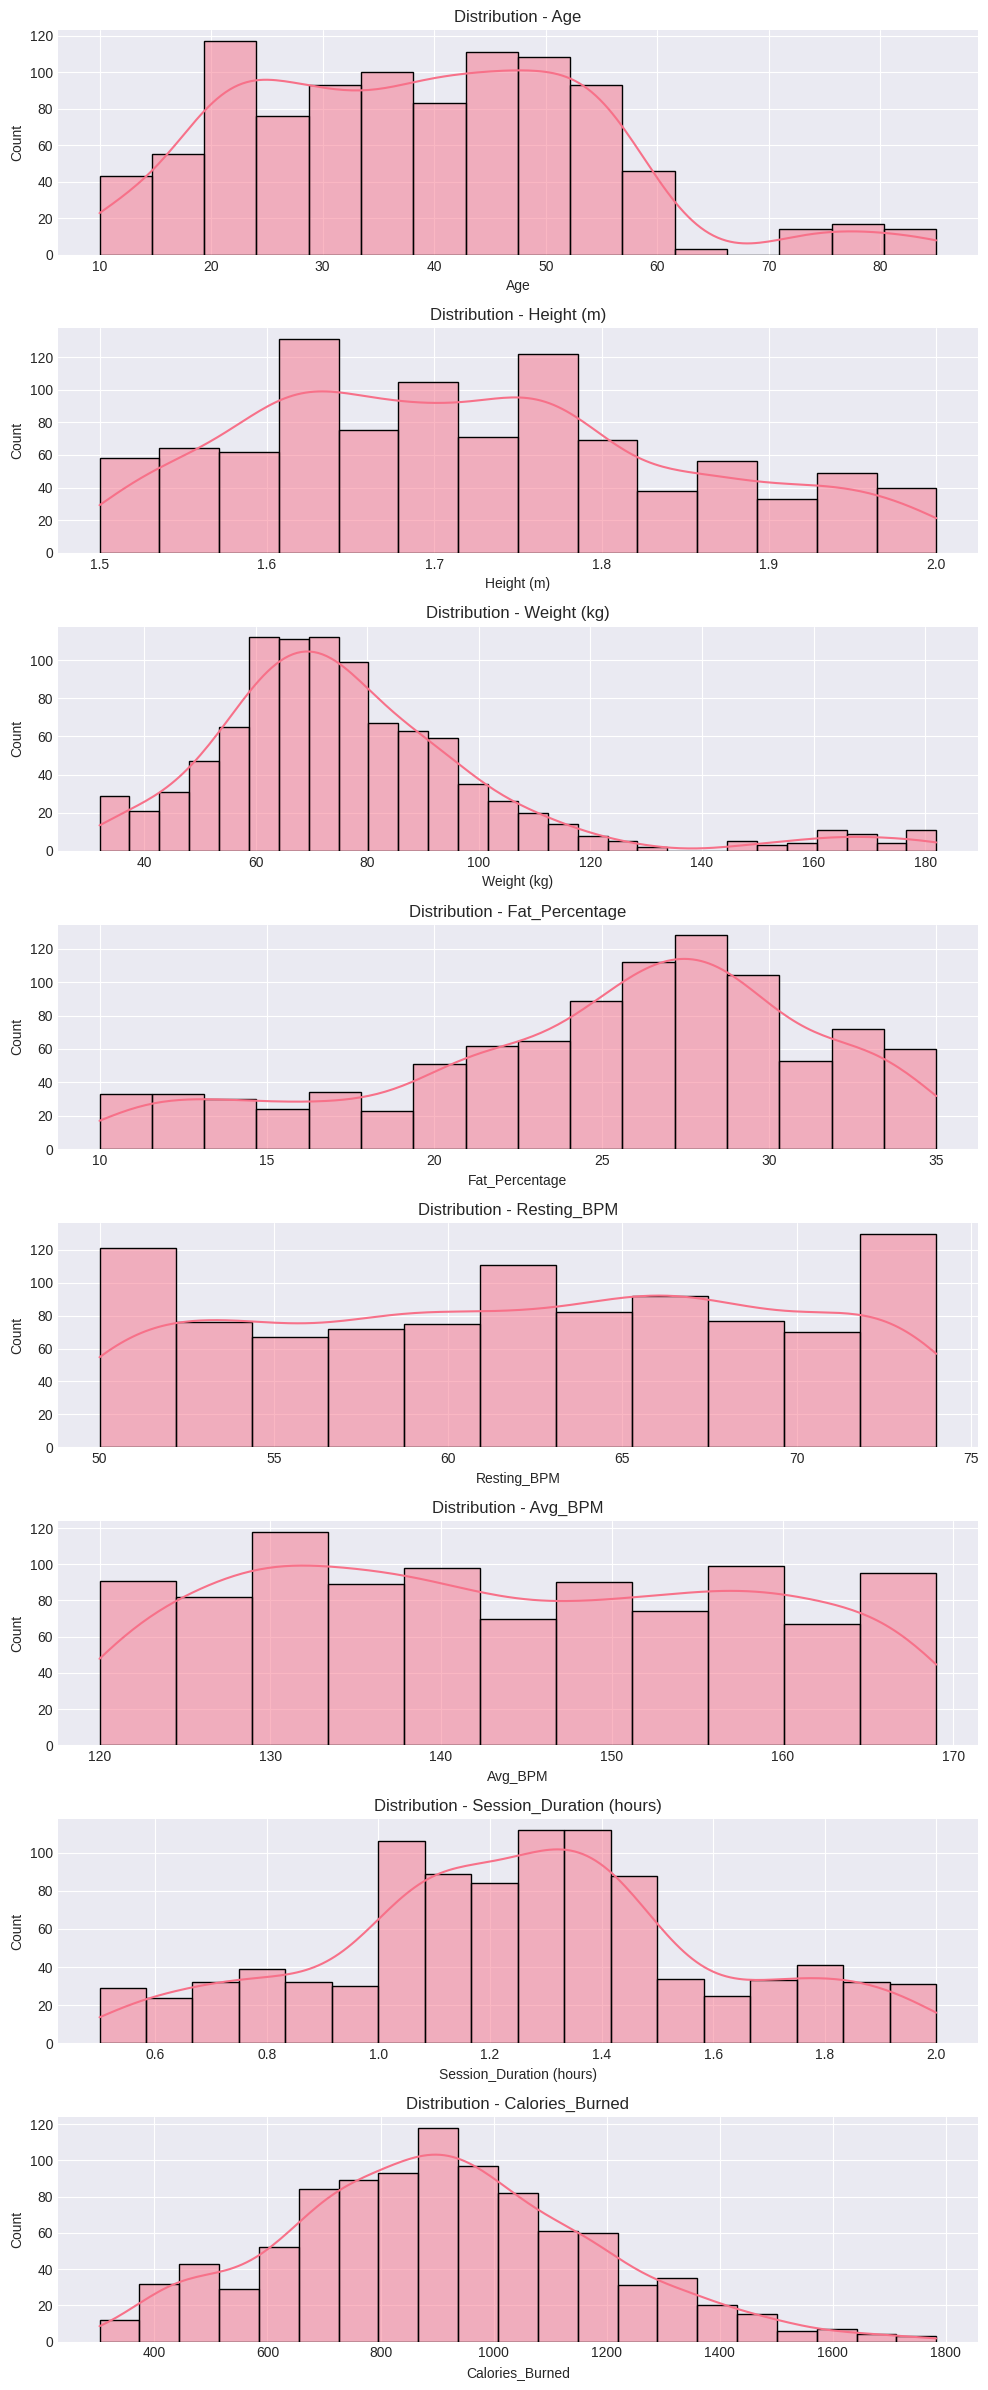

In [4]:
# Distributions principales (comme V3, mais orientées V6)
cols_to_plot = [
    'Age', 'Height (m)', 'Weight (kg)', 'Fat_Percentage',
    'Resting_BPM', 'Avg_BPM', 'Session_Duration (hours)', 'Calories_Burned'
]
cols_to_plot = [c for c in cols_to_plot if c in df_raw.columns]

fig, axes = plt.subplots(len(cols_to_plot), 1, figsize=(10, 3 * len(cols_to_plot)))
if len(cols_to_plot) == 1:
    axes = [axes]

for ax, col in zip(axes, cols_to_plot):
    sns.histplot(df_raw[col], kde=True, ax=ax)
    ax.set_title(f'Distribution - {col}')

plt.tight_layout()
plt.show()


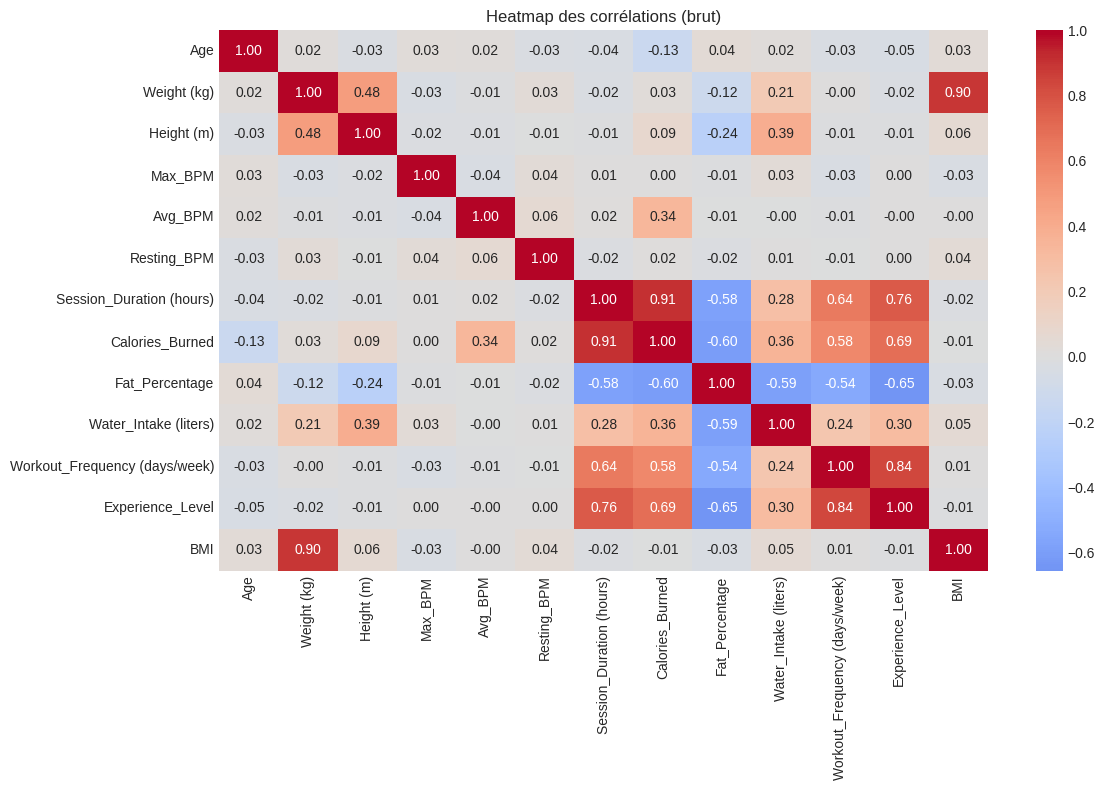

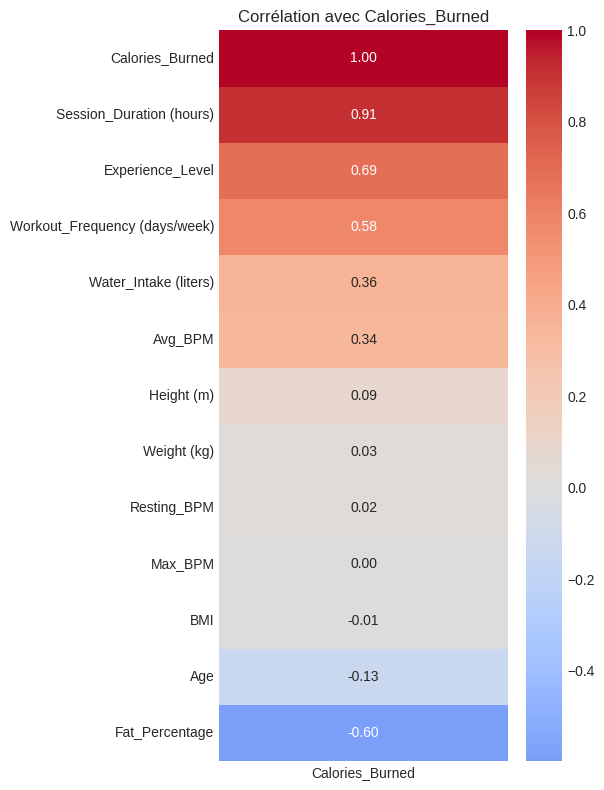

In [5]:
# Corrélations brutes (style V3)
num_df = df_raw.select_dtypes(include=['number'])
corr = num_df.corr(numeric_only=True)

plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Heatmap des corrélations (brut)')
plt.tight_layout()
plt.show()

if 'Calories_Burned' in corr.columns:
    plt.figure(figsize=(6, 8))
    corr_target = corr[['Calories_Burned']].sort_values('Calories_Burned', ascending=False)
    sns.heatmap(corr_target, annot=True, fmt='.2f', cmap='coolwarm', center=0)
    plt.title('Corrélation avec Calories_Burned')
    plt.tight_layout()
    plt.show()


## Préparation V6

Ajouts clés par rapport à V5:
- `Height (m)` incluse comme feature directe.
- `BMI_calc` recalculé pour homogénéité.
- `lean_mass_per_height` pour représenter la masse maigre relative au gabarit.


In [6]:
def to_intensity(score: pd.Series) -> pd.Series:
    q1, q2 = score.quantile([0.33, 0.66])

    def _map(x: float) -> str:
        if x <= q1:
            return 'faible'
        if x <= q2:
            return 'moyen'
        return 'eleve'

    return score.apply(_map)


def prepare_dataset_v6(df: pd.DataFrame) -> pd.DataFrame:
    data = df.copy()

    required_cols = [
        'Age', 'Height (m)', 'Weight (kg)', 'Fat_Percentage',
        'Avg_BPM', 'Resting_BPM', 'Session_Duration (hours)', 'Workout_Type'
    ]
    missing = [c for c in required_cols if c not in data.columns]
    if missing:
        raise ValueError(f'Colonnes manquantes pour V6: {missing}')

    data = data[
        (data['Age'].between(16, 80))
        & (data['Height (m)'].between(1.35, 2.15))
        & (data['Weight (kg)'].between(40, 170))
        & (data['Fat_Percentage'].between(5, 55))
        & (data['Session_Duration (hours)'].between(0.3, 3.0))
        & (data['Resting_BPM'].between(35, 110))
        & (data['Avg_BPM'].between(90, 210))
    ].copy()

    hr_max_theorique = 220 - data['Age']
    denom = (hr_max_theorique - data['Resting_BPM']).replace(0, np.nan)
    data['hr_ratio_reserve'] = (data['Avg_BPM'] - data['Resting_BPM']) / denom
    data['bpm_reserve'] = data['Avg_BPM'] - data['Resting_BPM']

    data['fat_mass_kg'] = data['Weight (kg)'] * (data['Fat_Percentage'] / 100.0)
    data['lean_mass_kg'] = data['Weight (kg)'] - data['fat_mass_kg']

    data['BMI_calc'] = data['Weight (kg)'] / (data['Height (m)'] ** 2)
    data['lean_mass_per_height'] = data['lean_mass_kg'] / data['Height (m)']

    data['effort_load'] = data['hr_ratio_reserve'] * data['Session_Duration (hours)'] * (data['Weight (kg)'] / 70.0)
    data['resting_to_lean_ratio'] = data['Resting_BPM'] / data['lean_mass_kg'].replace(0, np.nan)

    intensity_score = (
        0.54 * data['hr_ratio_reserve']
        + 0.16 * (data['Session_Duration (hours)'] / 2.0)
        + 0.10 * ((data['Avg_BPM'] - 100.0) / 100.0)
        + 0.08 * ((data['fat_mass_kg'] / data['Weight (kg)']) - 0.22)
        + 0.05 * ((data['BMI_calc'] - 24.0) / 10.0)
        + 0.04 * ((data['resting_to_lean_ratio'] * 10.0) - 0.8)
        + 0.03 * ((data['lean_mass_per_height'] - 35.0) / 10.0)
    )

    data['intensite'] = to_intensity(intensity_score)

    features = [
        'Age', 'Height (m)', 'Weight (kg)', 'Fat_Percentage',
        'Avg_BPM', 'Resting_BPM', 'Session_Duration (hours)', 'Workout_Type',
        'hr_ratio_reserve', 'bpm_reserve', 'effort_load',
        'fat_mass_kg', 'lean_mass_kg', 'BMI_calc',
        'lean_mass_per_height', 'resting_to_lean_ratio'
    ]

    model_df = data[features + ['intensite']].replace([np.inf, -np.inf], np.nan).dropna()
    return model_df


model_df = prepare_dataset_v6(df_raw)
print('Shape V6 :', model_df.shape)
print(model_df['intensite'].value_counts(normalize=True).round(3))
model_df.head()


Shape V6 : (889, 17)
intensite
eleve     0.340
faible    0.331
moyen     0.330
Name: proportion, dtype: float64


,Age,Height (m),Weight (kg),Fat_Percentage,Avg_BPM,Resting_BPM,Session_Duration (hours),Workout_Type,hr_ratio_reserve,bpm_reserve,effort_load,fat_mass_kg,lean_mass_kg,BMI_calc,lean_mass_per_height,resting_to_lean_ratio,intensite
0,54,1.71,61.0,12.6,157,60,1.69,Yoga,0.915094,97,1.347673,7.6860,53.3140,20.861120,31.177778,1.125408,eleve
1,49,1.53,63.1,33.9,151,66,1.30,HIIT,0.809524,85,0.948646,21.3909,41.7091,26.955444,27.260850,1.582388,eleve
2,30,1.66,65.8,33.4,122,54,1.11,Cardio,0.500000,68,0.521700,21.9772,43.8228,23.878647,26.399277,1.232235,faible
3,23,1.70,73.5,28.8,164,56,0.59,Strength,0.765957,108,0.474511,21.1680,52.3320,25.432526,30.783529,1.070091,moyen
4,37,1.79,73.4,29.2,158,68,0.64,Strength,0.782609,90,0.525198,21.4328,51.9672,22.908149,29.031955,1.308518,moyen


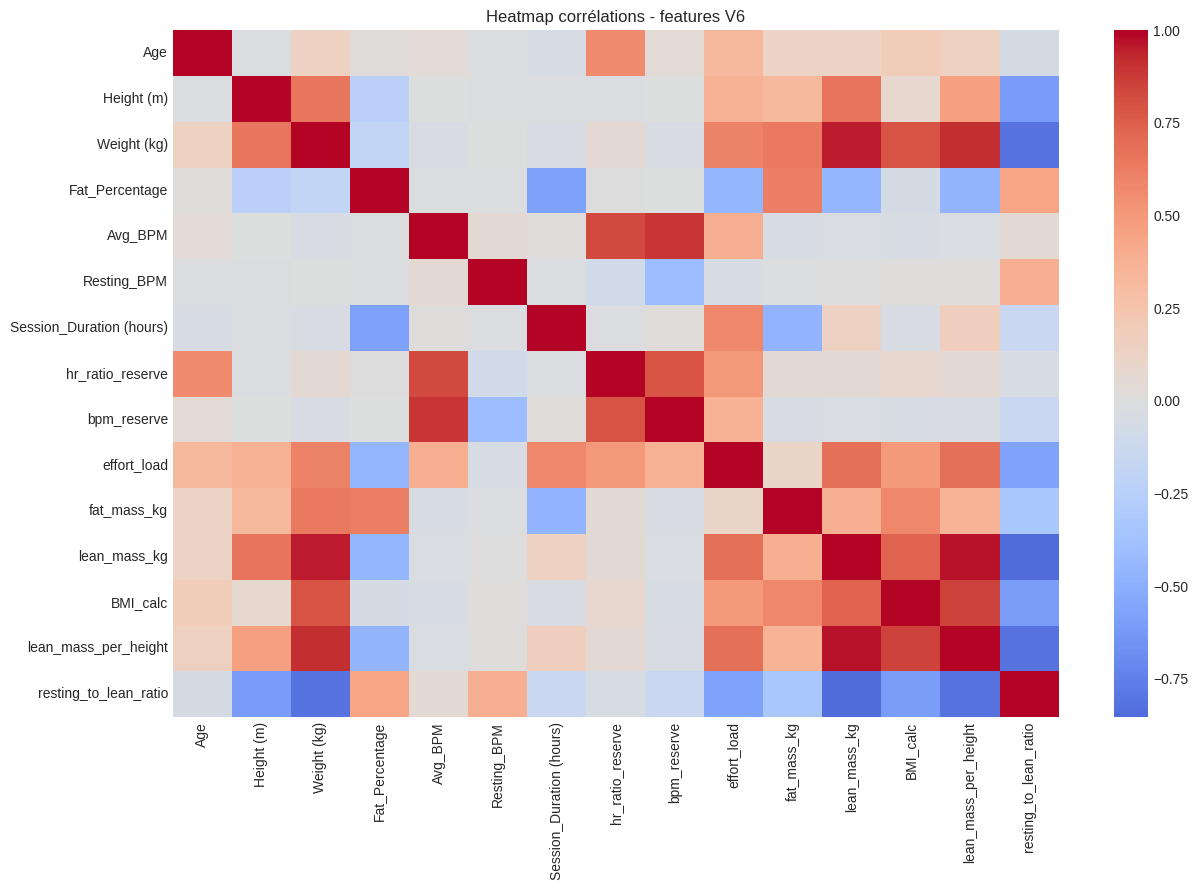

In [7]:
# Corrélations V6 (adaptation V3)
corr_v6 = model_df.select_dtypes(include=['number']).corr(numeric_only=True)

plt.figure(figsize=(13, 9))
sns.heatmap(corr_v6, annot=False, cmap='coolwarm', center=0)
plt.title('Heatmap corrélations - features V6')
plt.tight_layout()
plt.show()


## Split + entraînement des 3 modèles


In [8]:
X_raw = model_df.drop(columns=['intensite']).copy()
y = model_df['intensite'].copy()

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, random_state=42, stratify=y
)

print('X_train:', X_train_raw.shape, '| X_test:', X_test_raw.shape)
print('Distribution train:')
print(y_train.value_counts(normalize=True).round(3))


X_train: (711, 16) | X_test: (178, 16)
Distribution train:
intensite
eleve     0.340
faible    0.331
moyen     0.329
Name: proportion, dtype: float64


In [9]:
# Encodage RF / XGB
X_train_ohe = pd.get_dummies(X_train_raw, columns=['Workout_Type'], drop_first=True)
X_test_ohe = pd.get_dummies(X_test_raw, columns=['Workout_Type'], drop_first=True)
X_train_ohe, X_test_ohe = X_train_ohe.align(X_test_ohe, join='left', axis=1, fill_value=0)

rf = RandomForestClassifier(
    n_estimators=600,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1,
)
rf.fit(X_train_ohe, y_train)

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)

xgb = XGBClassifier(
    n_estimators=700,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    objective='multi:softprob',
    num_class=len(le.classes_),
    random_state=42,
    eval_metric='mlogloss',
    n_jobs=-1,
)
xgb.fit(X_train_ohe, y_train_enc)

num_cols = [
    'Age', 'Height (m)', 'Weight (kg)', 'Fat_Percentage',
    'Avg_BPM', 'Resting_BPM', 'Session_Duration (hours)',
    'hr_ratio_reserve', 'bpm_reserve', 'effort_load',
    'fat_mass_kg', 'lean_mass_kg', 'BMI_calc',
    'lean_mass_per_height', 'resting_to_lean_ratio'
]
cat_cols = ['Workout_Type']

preprocess = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
        ]), num_cols),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore')),
        ]), cat_cols),
    ]
)

lr = Pipeline([
    ('preprocess', preprocess),
    ('model', LogisticRegression(solver='lbfgs', max_iter=3000, class_weight='balanced', random_state=42)),
])
lr.fit(X_train_raw, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

## Évaluation test


In [10]:
def evaluate_classifier(name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    f1m = f1_score(y_true, y_pred, average='macro')
    print(f'[{name}] Accuracy: {acc:.4f} | F1 macro: {f1m:.4f}')
    print(classification_report(y_true, y_pred, digits=4))
    return {'Version': 'V6', 'Modele': name, 'Accuracy': acc, 'F1_macro': f1m}

rf_pred = rf.predict(X_test_ohe)
xgb_pred = le.inverse_transform(xgb.predict(X_test_ohe))
lr_pred = lr.predict(X_test_raw)

res_test_v6 = [
    evaluate_classifier('RandomForest', y_test, rf_pred),
    evaluate_classifier('XGBoost', y_test, xgb_pred),
    evaluate_classifier('LogisticRegression', y_test, lr_pred),
]

results_test_v6_df = pd.DataFrame(res_test_v6).sort_values('F1_macro', ascending=False)
display(results_test_v6_df.style.format({'Accuracy': '{:.4f}', 'F1_macro': '{:.4f}'}))


[RandomForest] Accuracy: 0.8652 | F1 macro: 0.8666
              precision    recall  f1-score   support

       eleve     0.9455    0.8667    0.9043        60
      faible     0.8966    0.8814    0.8889        59
       moyen     0.7692    0.8475    0.8065        59

    accuracy                         0.8652       178
   macro avg     0.8704    0.8652    0.8666       178
weighted avg     0.8708    0.8652    0.8668       178

[XGBoost] Accuracy: 0.9157 | F1 macro: 0.9158
              precision    recall  f1-score   support

       eleve     0.9492    0.9333    0.9412        60
      faible     0.9322    0.9322    0.9322        59
       moyen     0.8667    0.8814    0.8739        59

    accuracy                         0.9157       178
   macro avg     0.9160    0.9156    0.9158       178
weighted avg     0.9162    0.9157    0.9159       178

[LogisticRegression] Accuracy: 0.9944 | F1 macro: 0.9944
              precision    recall  f1-score   support

       eleve     1.0000    0.

,Version,Modele,Accuracy,F1_macro
2,V6,LogisticRegression,0.9944,0.9944
1,V6,XGBoost,0.9157,0.9158
0,V6,RandomForest,0.8652,0.8666


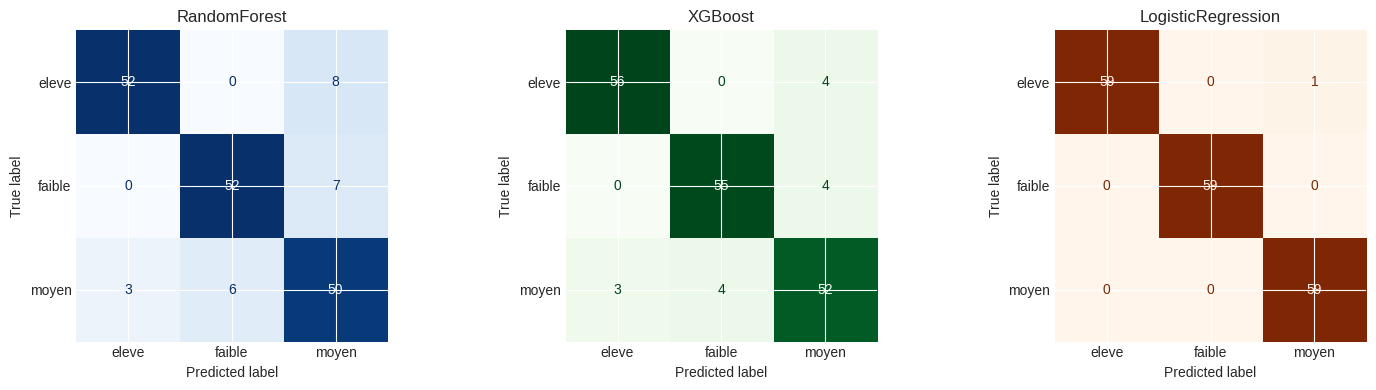

In [11]:
labels = sorted(y.unique())
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, name, pred, cmap in [
    (axes[0], 'RandomForest', rf_pred, 'Blues'),
    (axes[1], 'XGBoost', xgb_pred, 'Greens'),
    (axes[2], 'LogisticRegression', lr_pred, 'Oranges'),
]:
    cm = confusion_matrix(y_test, pred, labels=labels)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(ax=ax, cmap=cmap, colorbar=False)
    ax.set_title(name)

plt.tight_layout()
plt.show()


## Validation croisée 5-fold


In [12]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

X_ohe_full = pd.get_dummies(X_raw, columns=['Workout_Type'], drop_first=True)

rf_cv = RandomForestClassifier(n_estimators=600, random_state=42, class_weight='balanced', n_jobs=-1)
rf_scores = cross_val_score(rf_cv, X_ohe_full, y, cv=cv, scoring='f1_macro')

y_enc_full = LabelEncoder().fit_transform(y)
xgb_cv = XGBClassifier(
    n_estimators=700,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    objective='multi:softprob',
    num_class=3,
    random_state=42,
    eval_metric='mlogloss',
    n_jobs=-1,
)
xgb_scores = cross_val_score(xgb_cv, X_ohe_full, y_enc_full, cv=cv, scoring='f1_macro')

lr_scores = cross_val_score(lr, X_raw, y, cv=cv, scoring='f1_macro')

cv_results_v6 = pd.DataFrame({
    'Version': ['V6', 'V6', 'V6'],
    'Modele': ['RandomForest', 'XGBoost', 'LogisticRegression'],
    'F1_macro_mean': [rf_scores.mean(), xgb_scores.mean(), lr_scores.mean()],
    'F1_macro_std': [rf_scores.std(), xgb_scores.std(), lr_scores.std()],
}).sort_values('F1_macro_mean', ascending=False)

display(cv_results_v6.style.format({'F1_macro_mean': '{:.4f}', 'F1_macro_std': '{:.4f}'}))


,Version,Modele,F1_macro_mean,F1_macro_std
2,V6,LogisticRegression,0.9528,0.0219
1,V6,XGBoost,0.8998,0.0068
0,V6,RandomForest,0.8819,0.0169


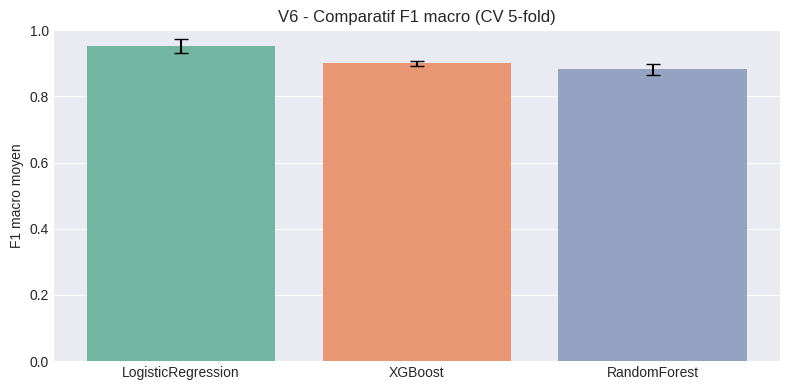

In [13]:
# Graphique comparatif V6 (style V3)
plt.figure(figsize=(8, 4))
sns.barplot(data=cv_results_v6, x='Modele', y='F1_macro_mean', palette='Set2')
for i, row in cv_results_v6.reset_index(drop=True).iterrows():
    plt.errorbar(i, row['F1_macro_mean'], yerr=row['F1_macro_std'], fmt='none', c='black', capsize=5)
plt.ylim(0.0, 1.0)
plt.title('V6 - Comparatif F1 macro (CV 5-fold)')
plt.xlabel('')
plt.ylabel('F1 macro moyen')
plt.tight_layout()
plt.show()


## Interprétabilité (comme V3, adaptée V6)


,importance
hr_ratio_reserve,0.172236
resting_to_lean_ratio,0.161861
Avg_BPM,0.123543
lean_mass_kg,0.069048
Weight (kg),0.058941
Height (m),0.056749
Resting_BPM,0.056635
effort_load,0.049179
Age,0.047476
bpm_reserve,0.047160


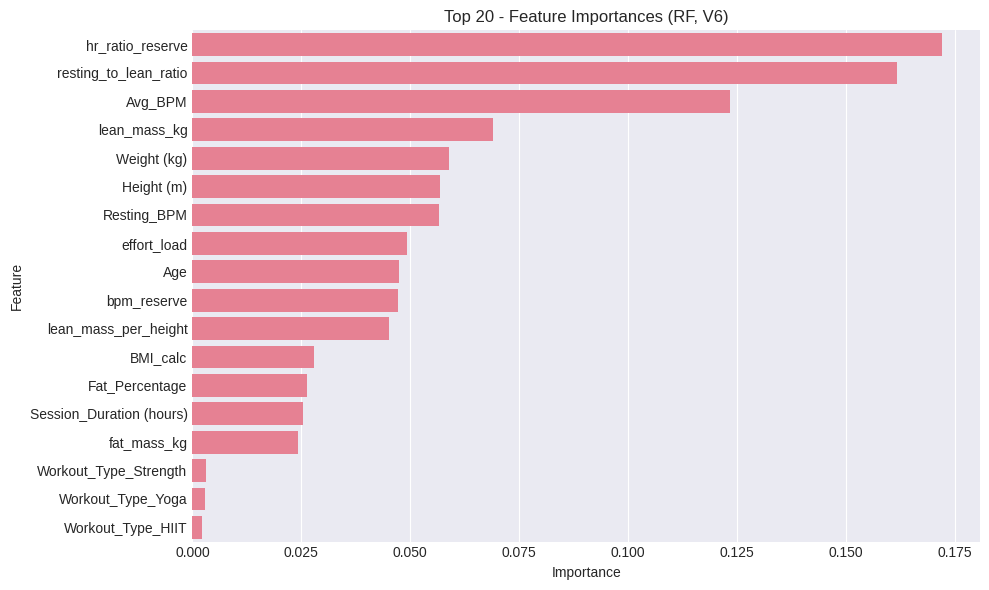

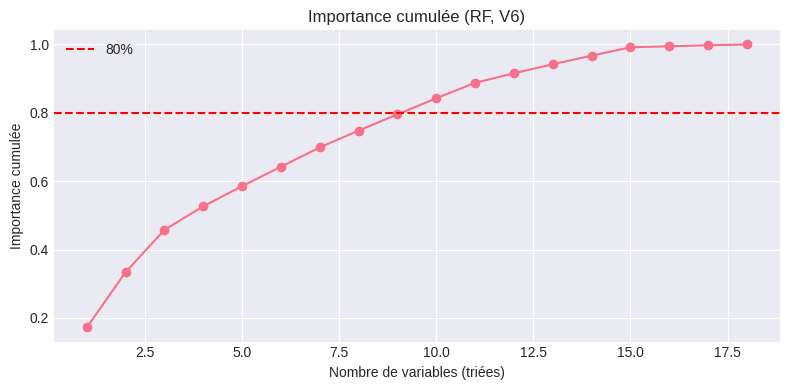

In [14]:
# Importances RF
importances = pd.Series(rf.feature_importances_, index=X_train_ohe.columns).sort_values(ascending=False)

top_n = 20
display(importances.head(top_n).to_frame('importance'))

plt.figure(figsize=(10, 6))
sns.barplot(x=importances.head(top_n).values, y=importances.head(top_n).index, orient='h')
plt.title(f'Top {top_n} - Feature Importances (RF, V6)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

cum = importances.cumsum()
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(cum) + 1), cum.values, marker='o')
plt.axhline(0.8, color='red', linestyle='--', label='80%')
plt.title('Importance cumulée (RF, V6)')
plt.xlabel('Nombre de variables (triées)')
plt.ylabel('Importance cumulée')
plt.legend()
plt.tight_layout()
plt.show()


## Comparaison V3 / V4 / V5 / V6

Remplis V3/V4/V5 après exécution de leurs notebooks.
La ligne V6 peut déjà être alimentée automatiquement.


In [15]:
# Template comparatif global (à compléter avec tes scores réels V3/V4/V5)
# Convention: métriques CV (mean) pour comparaison équitable.

comparison_template = pd.DataFrame([
    {'Version': 'V3', 'Modele': 'RandomForest', 'Accuracy_mean': np.nan, 'F1_macro_mean': np.nan},
    {'Version': 'V3', 'Modele': 'XGBoost', 'Accuracy_mean': np.nan, 'F1_macro_mean': np.nan},
    {'Version': 'V3', 'Modele': 'LogisticRegression', 'Accuracy_mean': np.nan, 'F1_macro_mean': np.nan},

    {'Version': 'V4', 'Modele': 'RandomForest', 'Accuracy_mean': np.nan, 'F1_macro_mean': np.nan},
    {'Version': 'V4', 'Modele': 'XGBoost', 'Accuracy_mean': np.nan, 'F1_macro_mean': np.nan},
    {'Version': 'V4', 'Modele': 'LogisticRegression', 'Accuracy_mean': np.nan, 'F1_macro_mean': np.nan},

    {'Version': 'V5', 'Modele': 'RandomForest', 'Accuracy_mean': np.nan, 'F1_macro_mean': np.nan},
    {'Version': 'V5', 'Modele': 'XGBoost', 'Accuracy_mean': np.nan, 'F1_macro_mean': np.nan},
    {'Version': 'V5', 'Modele': 'LogisticRegression', 'Accuracy_mean': np.nan, 'F1_macro_mean': np.nan},
])

# Injection automatique V6
v6_fill = pd.DataFrame([
    {'Version': 'V6', 'Modele': 'RandomForest', 'Accuracy_mean': np.nan, 'F1_macro_mean': rf_scores.mean()},
    {'Version': 'V6', 'Modele': 'XGBoost', 'Accuracy_mean': np.nan, 'F1_macro_mean': xgb_scores.mean()},
    {'Version': 'V6', 'Modele': 'LogisticRegression', 'Accuracy_mean': np.nan, 'F1_macro_mean': lr_scores.mean()},
])

comparison_df = pd.concat([comparison_template, v6_fill], ignore_index=True)
display(comparison_df)


,Version,Modele,Accuracy_mean,F1_macro_mean
0,V3,RandomForest,NaN,NaN
1,V3,XGBoost,NaN,NaN
2,V3,LogisticRegression,NaN,NaN
3,V4,RandomForest,NaN,NaN
4,V4,XGBoost,NaN,NaN
5,V4,LogisticRegression,NaN,NaN
6,V5,RandomForest,NaN,NaN
7,V5,XGBoost,NaN,NaN
8,V5,LogisticRegression,NaN,NaN
9,V6,RandomForest,NaN,0.881925


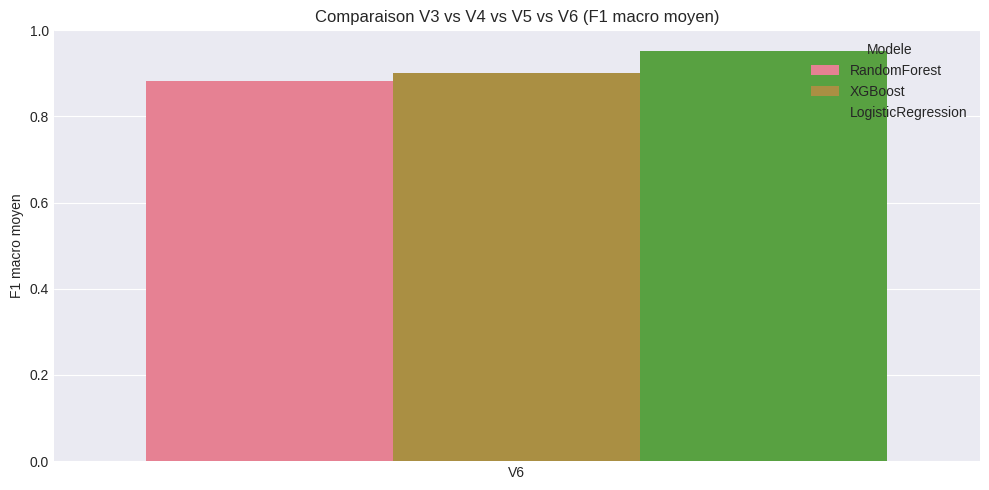

In [16]:
# Graphique de comparaison globale (fonctionnera pleinement quand V3/V4/V5 seront remplis)
plot_df = comparison_df.dropna(subset=['F1_macro_mean']).copy()

if plot_df.empty:
    print('Remplis les métriques V3/V4/V5 pour générer la comparaison complète.')
else:
    plt.figure(figsize=(10, 5))
    sns.barplot(data=plot_df, x='Version', y='F1_macro_mean', hue='Modele')
    plt.ylim(0.0, 1.0)
    plt.title('Comparaison V3 vs V4 vs V5 vs V6 (F1 macro moyen)')
    plt.ylabel('F1 macro moyen')
    plt.xlabel('')
    plt.tight_layout()
    plt.show()


## Sauvegarde artefacts V6 (optionnel)


In [17]:
# Décommente pour sauvegarder les modèles V6
# import joblib
# artifacts_dir = BASE_DIR / 'artifacts_intensite_v6'
# artifacts_dir.mkdir(exist_ok=True)
#
# joblib.dump(rf, artifacts_dir / 'rf_v6.joblib')
# joblib.dump(xgb, artifacts_dir / 'xgb_v6.joblib')
# joblib.dump(lr, artifacts_dir / 'lr_v6.joblib')
# joblib.dump(le, artifacts_dir / 'label_encoder_xgb_v6.joblib')
# pd.Series(X_train_ohe.columns).to_csv(artifacts_dir / 'rf_xgb_columns_v6.csv', index=False)
# print('Artefacts V6 sauvegardés dans', artifacts_dir)


## Conclusion (à compléter après tests)

A compléter après avoir exécuté V3/V4/V5/V6 et renseigné le tableau comparatif.

- Version retenue:
- Modèle retenu:
- Justification métier + métriques:
- Limites:
- Prochaine étape:
